In [1]:
import sys
from pathlib import Path
import inspect
import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
SOURCE=Path('/home/xueshuailin/CCC_Phe/V1004/src')
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0,str(SOURCE))
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression
from phenoniche.v1002.final_model import fit_balanced
from phenoniche.v1004.composition_ccc_hierarchy import build_hierarchical_states
from phenoniche.v1004.radius_context import (
    build_radius_context, radius_composition, aggregate_radius_pairwise_ccc)

ROOT=Path('/data1/xueshuailin/CCC_Phe_Niche')
OUTPUT=SOURCE.parent/'outputs/hbc1_hierarchical_niches_r200'
OUTPUT.mkdir(parents=True,exist_ok=True)
assert all(Path(inspect.getfile(fn)).resolve().is_relative_to(SOURCE)
           for fn in (build_radius_context, radius_composition, aggregate_radius_pairwise_ccc,
                      load_lr_atlas, fit_balanced, build_hierarchical_states))
MICROENV_RADIUS_UM=200.0  # membership: all cells within this physical radius
SIGMA_UM=20.0  # existing anchor weights and pairwise CCC Gaussian kernel
PAIR_CUTOFF_UM=5*SIGMA_UM  # numerical Gaussian-tail cutoff, not context radius
K_NICHE=8
SEED=40700
DEVICE=('cuda:1' if torch.cuda.device_count()>1 else
        'cuda:0' if torch.cuda.is_available() else 'cpu')
BATCH=16
assert (MICROENV_RADIUS_UM,SIGMA_UM,K_NICHE,SEED)==(200.0,20.0,8,40700)
assert PAIR_CUTOFF_UM==100.0
json.dump({'neighborhood_type':'fixed_radius','radius_um':MICROENV_RADIUS_UM,
           'ccc_sigma_um':SIGMA_UM,'pair_kernel_numerical_cutoff_um':PAIR_CUTOFF_UM,
           'seed':SEED,'K':K_NICHE,'NMF_iterations':500},
          open(OUTPUT/'metadata.json','w'),indent=2)
plt.rcParams.update({'font.size':10,'figure.dpi':120,'savefig.dpi':220})


In [2]:
path=ROOT/'data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_FFPE_Human_Breast_Cancer_Rep1'
assert adata.obs.cell_id.is_unique and adata.obs_names.equals(pd.Index(adata.obs.cell_id))
assert np.isfinite(adata.obsm['spatial']).all()
coordinates=adata.obsm['spatial'].astype(np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
assert (cell_type>=0).all()
T=len(label_categories); N=adata.n_obs
assert len(coordinates)==len(cell_type)==N and T==20


In [3]:
context=build_radius_context(coordinates,radius_um=MICROENV_RADIUS_UM,
                             anchor_sigma_um=SIGMA_UM)
neighbor_counts=context.counts
assert len(neighbor_counts)==N and neighbor_counts.min()>=2
assert context.radius_um==200.0 and context.anchor_sigma_um==20.0

# Independent brute-force audit of 20 fixed-seed anchors. The builder also
# checks the radius bound for every member in every construction batch.
audit_rng=np.random.default_rng(SEED)
for anchor in audit_rng.choice(N,size=20,replace=False):
    ids,_=context.members(int(anchor))
    distance2=np.sum((coordinates.astype(np.float64)-coordinates[anchor].astype(np.float64))**2,axis=1)
    brute=np.flatnonzero(distance2<=MICROENV_RADIUS_UM**2)
    assert np.array_equal(ids,brute)
    assert np.all(distance2[ids]<=MICROENV_RADIUS_UM**2)
summary={
    'median':float(np.median(neighbor_counts)),
    'Q25':float(np.quantile(neighbor_counts,.25)),
    'Q75':float(np.quantile(neighbor_counts,.75)),
    'min':int(neighbor_counts.min()),'max':int(neighbor_counts.max()),
    'fraction_lt_30':float(np.mean(neighbor_counts<30)),
    'fraction_gt_100':float(np.mean(neighbor_counts>100)),
    'fraction_gt_500':float(np.mean(neighbor_counts>500)),
    'fraction_gt_1000':float(np.mean(neighbor_counts>1000)),
}
pd.DataFrame([{'metric':key,'value':value} for key,value in summary.items()]).to_csv(
    OUTPUT/'neighborhood_size_summary.csv',index=False)
print(f'Neighborhood definition: fixed radius = {MICROENV_RADIUS_UM:g} µm; '
      f'cells median={summary["median"]:g}, Q25={summary["Q25"]:g}, '
      f'Q75={summary["Q75"]:g}, min={summary["min"]}, max={summary["max"]}; '
      f'<30={summary["fraction_lt_30"]:.3f}, >100={summary["fraction_gt_100"]:.3f}, '
      f'>500={summary["fraction_gt_500"]:.3f}, >1000={summary["fraction_gt_1000"]:.3f}')
C=radius_composition(context,cell_type,T)
assert C.shape==(N,T) and np.allclose(C.sum(1),1,atol=1e-5)

atlas=load_lr_atlas(str(SOURCE.parent/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(row for row in atlas.interactions if all(g in panel for g in row.ligand_components+row.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
if not measurable: raise RuntimeError('No fully measurable LR interaction in the Xenium panel')
lr_genes=tuple(sorted({g for row in measurable for g in row.ligand_components+row.receptor_components}))
expression=np.column_stack([adata[:,gene].X.toarray().ravel() for gene in lr_genes]).astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas)

# Opportunity uses the same radius members, physical-pair exclusion and pair
# kernel as the CCC numerator. 5*sigma limits only negligible pair-kernel tails.
_,opportunity=aggregate_radius_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,context,sigma_um=SIGMA_UM,
    pair_cutoff_um=PAIR_CUTOFF_UM,batch_size=BATCH,device=DEVICE,
    compute_signal=False)
pair_support=(opportunity>0).sum(0)
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
supported=pair_support>=max(20,int(np.ceil(.01*N)))
feature_mask=(coverage&supported[:,None]).reshape(-1)
final_ccc=int(feature_mask.sum())
if final_ccc==0: raise RuntimeError('No directed CCC feature passed the fixed outcome-blind filter')
I=np.empty((N,final_ccc),dtype=np.float32)
I,signal_opportunity=aggregate_radius_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,context,sigma_um=SIGMA_UM,
    feature_mask=feature_mask,pair_cutoff_um=PAIR_CUTOFF_UM,
    batch_size=BATCH,device=DEVICE,communication_out=I,
    opportunity_input=opportunity)
assert signal_opportunity is opportunity
del signal_opportunity
assert I.shape==(N,final_ccc) and np.isfinite(I).all()


Neighborhood definition: fixed radius = 200 µm; cells median=725, Q25=563, Q75=863, min=6, max=1579; <30=0.000, >100=0.984, >500=0.803, >1000=0.121


In [4]:
fit_C=fit_balanced({'HC':C},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
fit_I=fit_balanced({'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
W_C=np.maximum(fit_C.W.numpy(),0)
W_I=np.maximum(fit_I.W.numpy(),0)
W_C/=np.maximum(W_C.sum(1,keepdims=True),1e-12)
W_I/=np.maximum(W_I.sum(1,keepdims=True),1e-12)
c_labels=W_C.argmax(1)
i_labels=W_I.argmax(1)
assert len(coordinates)==len(cell_type)==C.shape[0]==I.shape[0]==W_C.shape[0]==W_I.shape[0]==N
assert W_C.shape==W_I.shape==(N,K_NICHE)

assert len(c_labels)==len(i_labels)==N
assert np.isfinite(W_C).all() and np.isfinite(W_I).all()


In [5]:
joint_id,joint_mapping=build_hierarchical_states(c_labels,i_labels,K_NICHE)
assert len(joint_id)==N and sum(row['n_cells'] for row in joint_mapping)==N
assert np.array_equal(np.array([(joint_mapping[j-1]['C_state'],joint_mapping[j-1]['I_state'])
                                for j in joint_id]),np.column_stack((c_labels,i_labels)))
pd.DataFrame({'cell_id':adata.obs.cell_id.to_numpy(),'x':coordinates[:,0],
              'y':coordinates[:,1],'cell_type':adata.obs.cell_type_coarse.to_numpy(),
              'n_cells_within_200um':neighbor_counts,
              'C_state':c_labels,'I_state':i_labels,'joint_id':joint_id}).to_csv(
                  OUTPUT/'cell_states.csv',index=False)
pd.DataFrame(joint_mapping).to_csv(OUTPUT/'joint_state_mapping.csv',index=False)

# Retain the existing tab10 composition colors: C0 is #1f77b4 (blue).
single_colors=plt.get_cmap('tab10',K_NICHE)(np.arange(K_NICHE))
type_colors=plt.get_cmap('tab20',T)(np.arange(T))
assert mcolors.to_hex(single_colors[0])=='#1f77b4'
blue_state=next(k for k,color in enumerate(single_colors)
                if mcolors.to_hex(color)=='#1f77b4')

def joint_color(c,i):
    base=np.asarray(single_colors[c,:3])
    if i<=4:
        white_mix=(4-i)*0.14
        return base*(1-white_mix)+np.ones(3)*white_mix
    darkness=(i-4)*0.16
    return base*(1-darkness)

joint_palette={row['joint_id']:joint_color(row['C_state'],row['I_state'])
               for row in joint_mapping}
joint_rgb=np.stack([joint_palette[j] for j in joint_id])

def save_spatial(colors,title,filename,legend=None):
    fig,ax=plt.subplots(figsize=(11,8))
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(xlim=(coordinates[:,0].min(),coordinates[:,0].max()),
           ylim=(coordinates[:,1].max(),coordinates[:,1].min()),title=title)
    ax.set_aspect('equal'); ax.set_axis_off()
    if legend is not None:
        ax.legend(handles=legend,bbox_to_anchor=(1.01,1),loc='upper left',
                  frameon=False,fontsize=8,ncol=1)
        fig.subplots_adjust(right=.76)
    fig.savefig(OUTPUT/filename,bbox_inches='tight')
    plt.show()


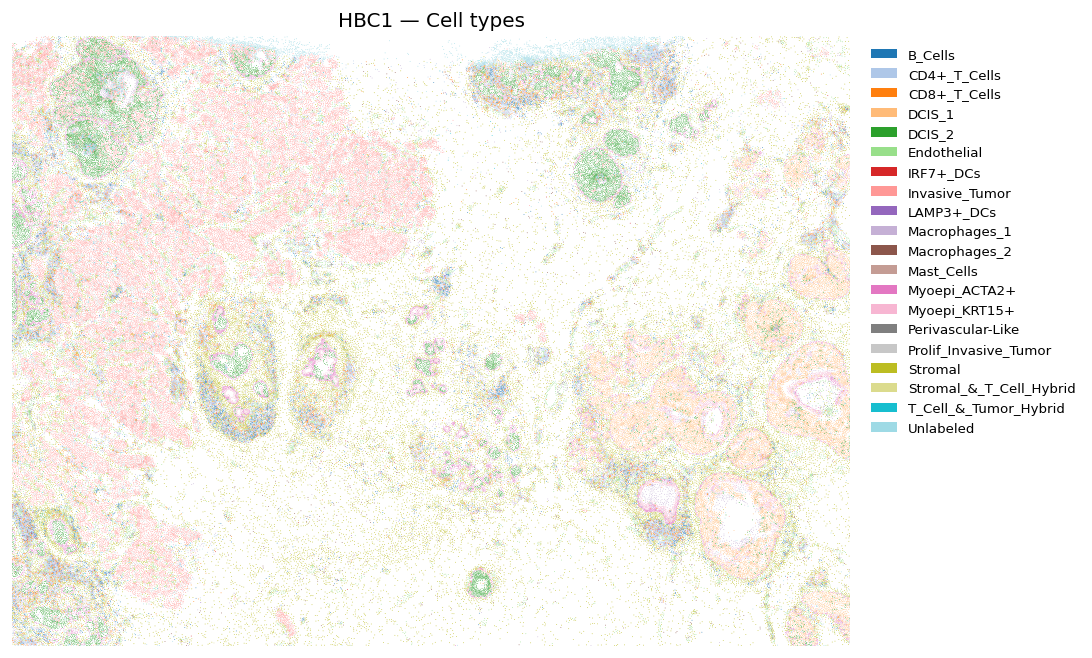

In [6]:
legend=[Patch(facecolor=type_colors[j],label=name)
        for j,name in enumerate(label_categories)]
save_spatial(type_colors[cell_type],'HBC1 — Cell types','HBC1_cell_types.png',legend)


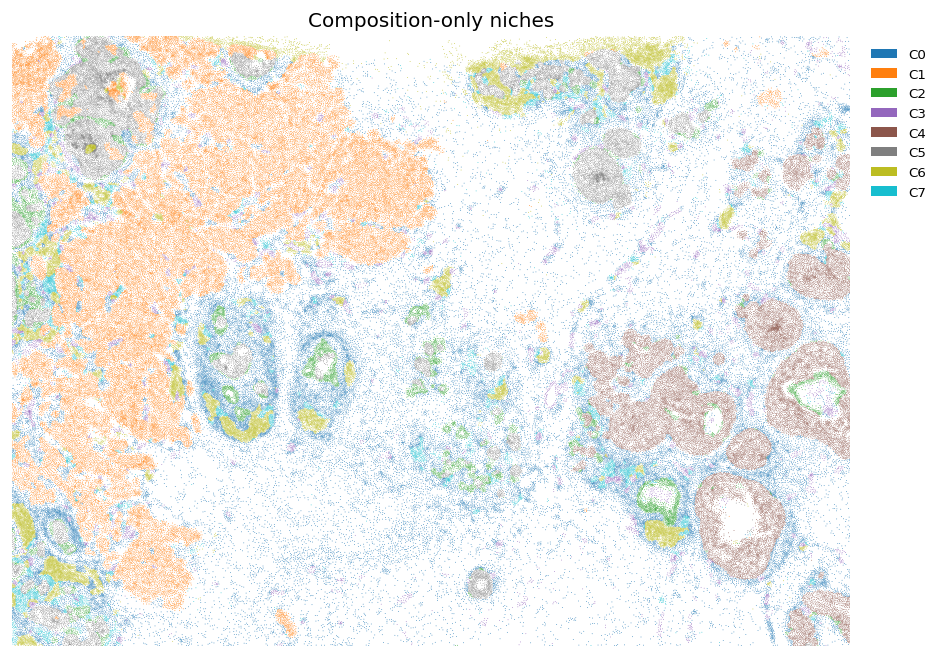

In [7]:
legend=[Patch(facecolor=single_colors[j],label=f'C{j}') for j in range(K_NICHE)]
save_spatial(single_colors[c_labels],'Composition-only niches',
             'HBC1_composition_only.png',legend)


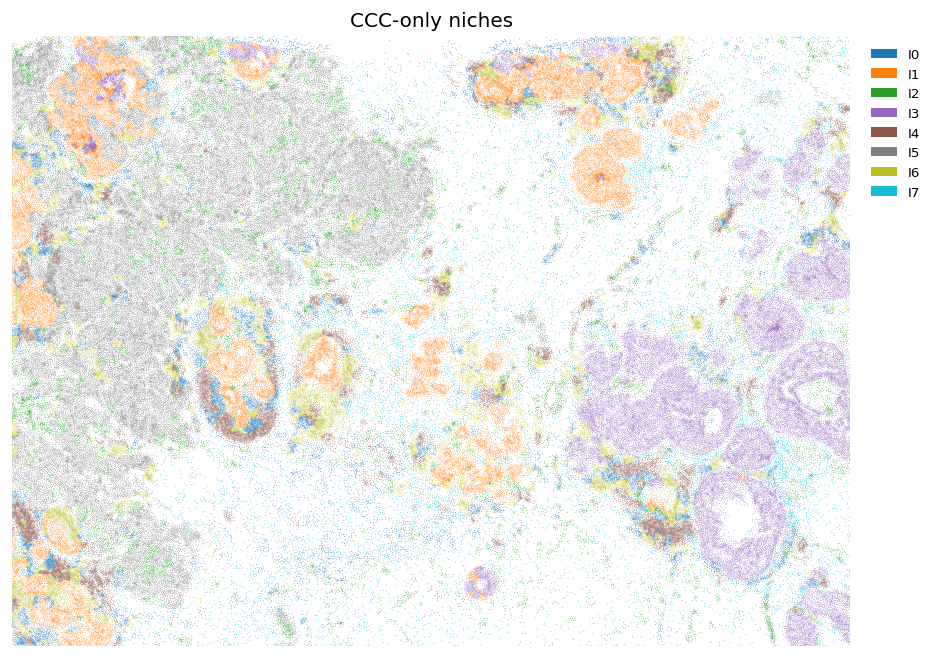

In [8]:
legend=[Patch(facecolor=single_colors[j],label=f'I{j}') for j in range(K_NICHE)]
save_spatial(single_colors[i_labels],'CCC-only niches','HBC1_CCC_only.png',legend)


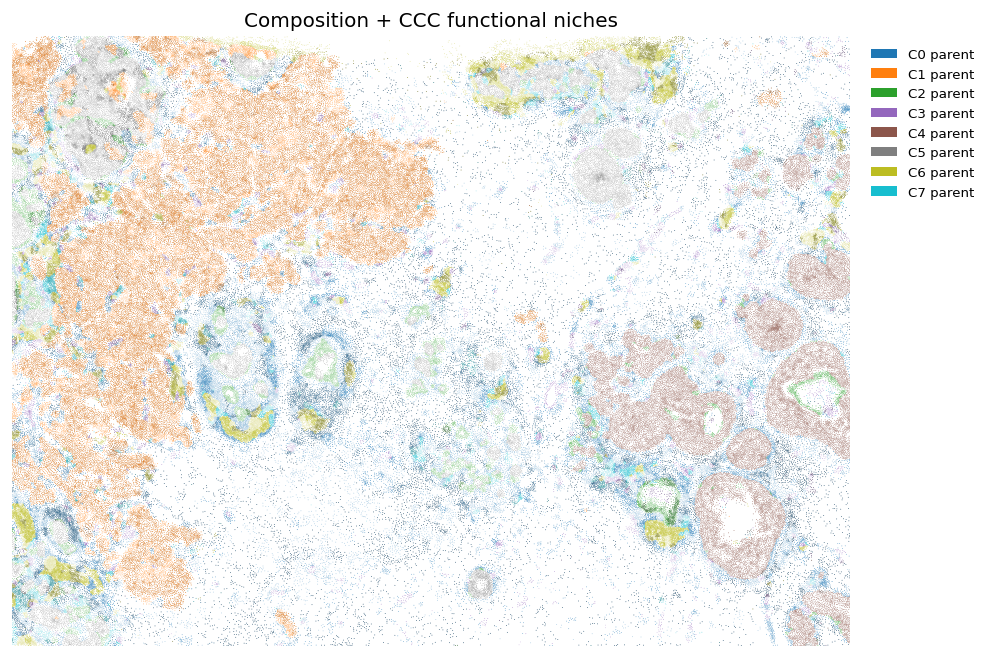

In [9]:
# One parent color family per C state; the I label changes only its shade.
legend=[Patch(facecolor=single_colors[j],label=f'C{j} parent') for j in range(K_NICHE)]
save_spatial(joint_rgb,'Composition + CCC functional niches',
             'HBC1_joint_hierarchical.png',legend)


Target composition state: C0; Region A dominant CCC state: 3; Region B dominant CCC state: 6


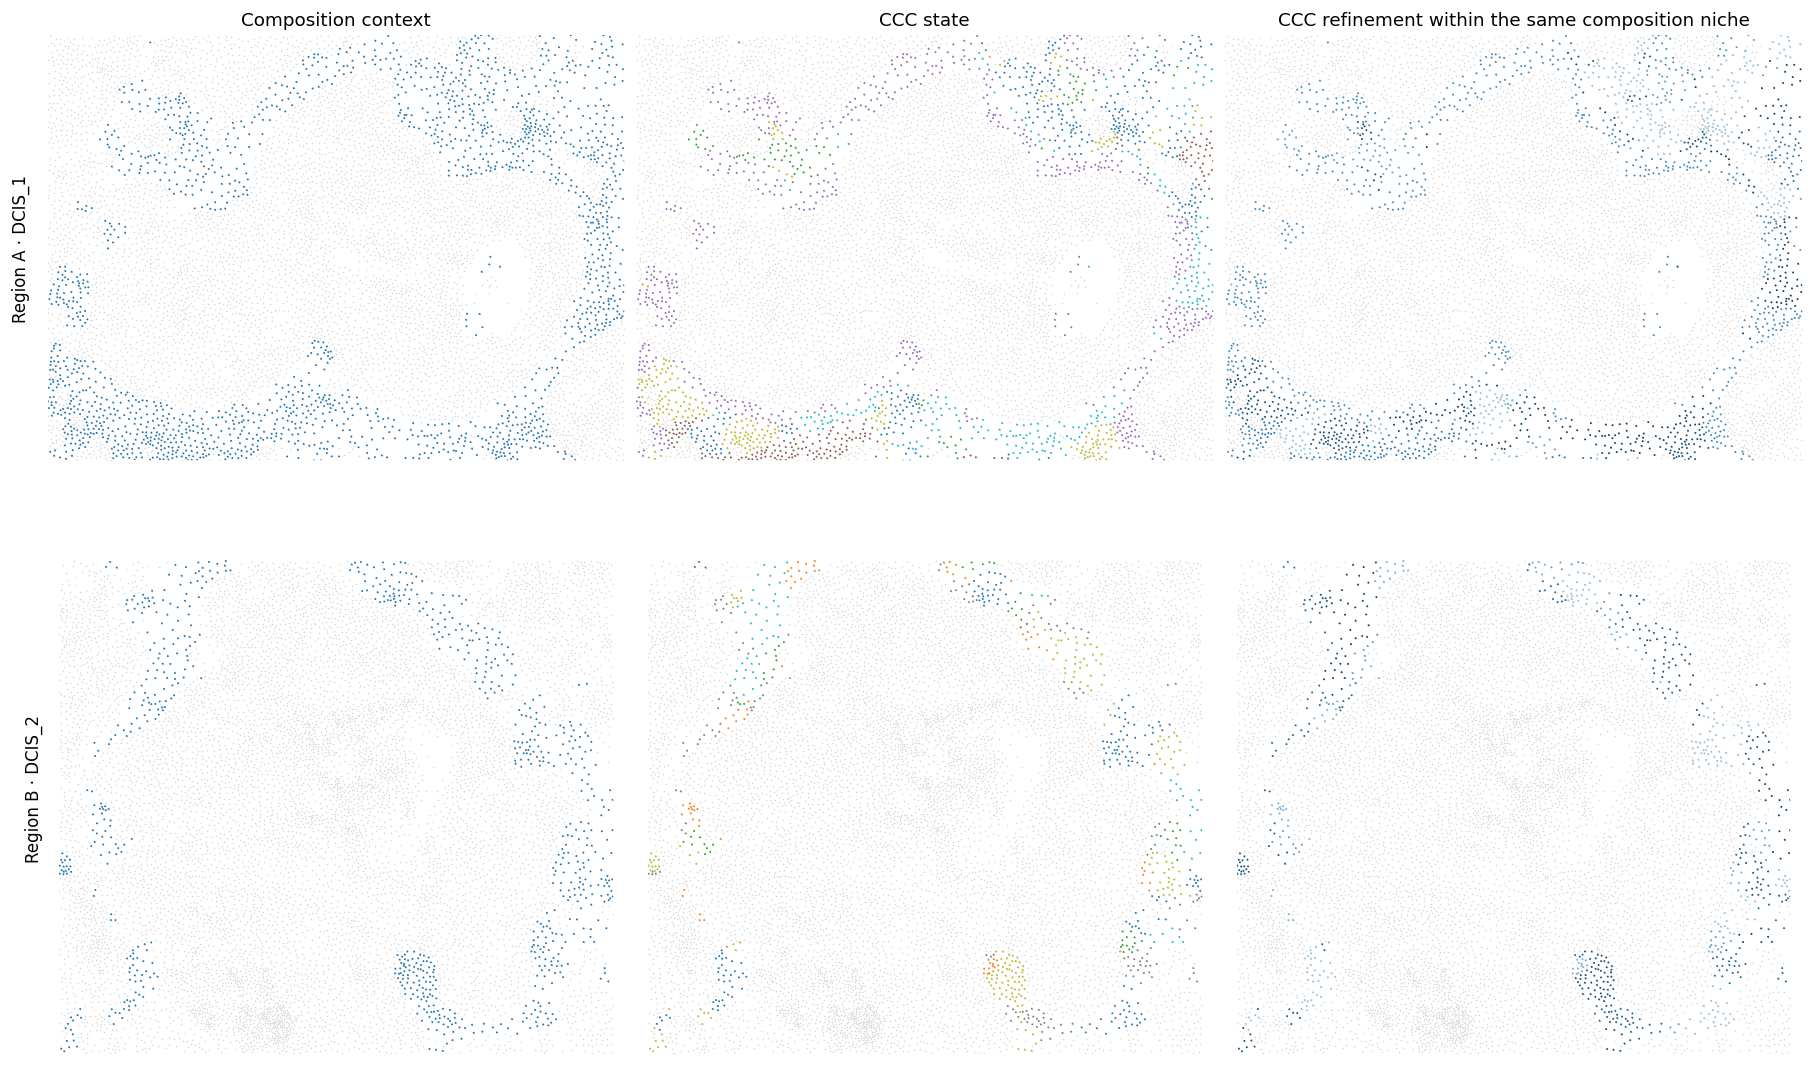

In [10]:
# Spatially define region A/B before looking at CCC labels: largest connected
# DCIS_1 and DCIS_2 components. A fixed 20 µm adjacency is used only to
# delineate anatomical structures for this figure, never for C or I contexts.
regions=[]
for name in ('DCIS_1','DCIS_2'):
    indices=np.flatnonzero(cell_type==label_categories.index(name))
    edges=cKDTree(coordinates[indices]).query_pairs(SIGMA_UM,output_type='ndarray')
    local_graph=csr_matrix((np.ones(len(edges),dtype=np.uint8),
                            (edges[:,0],edges[:,1])),shape=(len(indices),len(indices)))
    _,component=connected_components(local_graph+local_graph.T,directed=False)
    largest=int(np.bincount(component).argmax())
    core=indices[component==largest]
    xy=coordinates[core]
    pad=5*SIGMA_UM   # fixed 100 µm, derived from the existing spatial scale
    box=(float(xy[:,0].min()-pad),float(xy[:,0].max()+pad),
         float(xy[:,1].min()-pad),float(xy[:,1].max()+pad))
    roi=(coordinates[:,0]>=box[0])&(coordinates[:,0]<=box[1])&(
         coordinates[:,1]>=box[2])&(coordinates[:,1]<=box[3])
    blue=roi&(c_labels==blue_state)
    dominant=(int(np.bincount(i_labels[blue],minlength=K_NICHE).argmax())
              if blue.any() else None)
    regions.append((name,box,roi,blue,dominant))
print(f'Target composition state: C{blue_state}; '
      f'Region A dominant CCC state: {regions[0][4]}; '
      f'Region B dominant CCC state: {regions[1][4]}')

# Each column is one view; the two rows use the identical region/cell indices.
fig,axes=plt.subplots(2,3,figsize=(15,9),constrained_layout=True)
for row,(name,box,roi,blue,dominant) in enumerate(regions):
    ids=np.flatnonzero(roi)
    for col,ax in enumerate(axes[row]):
        ax.scatter(coordinates[ids,0],coordinates[ids,1],
                   c='#d8d8d8',s=.9,linewidths=0,rasterized=True)
        chosen=ids[c_labels[ids]==blue_state]
        colors=(np.tile(single_colors[blue_state],(len(chosen),1)) if col==0 else
                single_colors[i_labels[chosen]] if col==1 else joint_rgb[chosen])
        ax.scatter(coordinates[chosen,0],coordinates[chosen,1],
                   c=colors,s=1.35,linewidths=0,rasterized=True)
        ax.set(xlim=(box[0],box[1]),ylim=(box[3],box[2]))
        ax.set_aspect('equal'); ax.set_axis_off()
        if col==0: ax.text(-.03,.5,f'Region {"AB"[row]} · {name}',
                           rotation=90,va='center',ha='right',transform=ax.transAxes)
for ax,title in zip(axes[0],('Composition context','CCC state',
                             'CCC refinement within the same composition niche')):
    ax.set_title(title,fontsize=11)
fig.savefig(OUTPUT/'HBC1_DCIS_comparison.png',bbox_inches='tight')
plt.show()


With the fixed 200 µm context, the selected DCIS_1 and DCIS_2 regions both contain blue C0 cells, but C0 accounts for only 24.1% and 8.1% of their ROI cells, respectively. Within C0, the most frequent CCC states differ (I3: 37.8% in DCIS_1; I6: 25.7% in DCIS_2), and both distributions are mixed. This is evidence of distinct common CCC substates within a shared composition subpopulation, not of two compositionally equivalent whole regions or a clean separation.